# ❤️ Heart Disease Prediction — Complete End-to-End Analysis Notebook
# By Vansh Chopra (4M028) INT375
> **Dataset**: `heart_dataset.csv` — 12,687 real patient records, 28 features  
> **Goal**: Identify patients at risk of heart disease using exploratory analysis and make a prediction model

---

## 📋 Table of Contents
1. [Environment Setup & Imports](#1)
2. [Load Dataset & Overview](#2)
3. [Numeric Feature Distributions](#3)
4. [Categorical Features vs Target](#4)
5. [Feature Correlation Heatmap](#5)
6. [Age, Gender & Risk Level Analysis](#6)
7. [Boxplots — Clinical Features vs Disease](#7)
8. [Temporal Analysis of Patient Visits](#8)
9. [Hospital & Doctor Analysis](#9)
10. [Lifestyle Factors vs Heart Disease](#10)
11. [Preprocessing & Feature Engineering](#11)
12. [Model Training — Six Classifiers](#12)
13. [Confusion Matrices — All Models](#13)
14. [ROC & Precision-Recall Curves](#14)
15. [Model Performance Comparison](#15)
16. [Feature Importance — RF & Gradient Boosting](#16)
17. [Clinical Feature Distributions (Post-Model View)](#17)
18. [Clinical Risk Scoring Engine](#18)
19. [Cross-Validation & Final Summary](#19)


---
## 1. Environment Setup & Imports <a id='1'></a>

All libraries used across the notebook are imported here.

| Library | Purpose |
|---------|---------|
| `pandas` / `numpy` | Data loading, wrangling, numerical ops |
| `matplotlib` / `seaborn` | All visualizations |
| `scikit-learn` | Preprocessing, models, evaluation metrics |
| `warnings` | Suppress non-critical deprecation noise |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm_mod
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                     f1_score, roc_auc_score, confusion_matrix,
                                     roc_curve, auc, precision_recall_curve,
                                     average_precision_score, classification_report)

# ── Global plotting style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'figure.dpi'        : 110,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

COLORS = ['#2196F3', '#F44336']   # blue = No Disease, red = Heart Disease
SEED   = 42
np.random.seed(SEED)

print("✅ All libraries loaded.")


✅ All libraries loaded.


---
## 2. Load Dataset & Overview <a id='2'></a>

### Dataset: `heart_dataset.csv`

| Property | Value |
|---------|-------|
| Rows | 12,687 patients |
| Columns | 28 features |
| Target | Binary — 0 = No Disease, 1 = Heart Disease |
| Disease rate | ~53.7 % |

### Feature Overview

| Column | Type | Description |
|--------|------|-------------|
| `Age` | int | Patient age (years) |
| `Sex` | binary | 0 = Female, 1 = Male |
| `Chest_Pain_Type` | ordinal 0-3 | Type of chest pain |
| `Trestbps` | int | Resting blood pressure (mmHg) |
| `Cholesterol` | int | Serum cholesterol (mg/dl) |
| `Fasting_Blood_Sugar` | binary | >120 mg/dl = 1 |
| `Resting_ECG` | ordinal 0-2 | ECG result at rest |
| `Max_Heart_Rate` | int | Maximum heart rate achieved |
| `Exercise_Induced_Angina` | binary | 1 = Yes |
| `ST_Depression` | float | ECG depression relative to rest |
| `Slope` | ordinal 0-2 | Slope of peak exercise ST segment |
| `Major_Vessels` | ordinal 0-3 | # vessels coloured by fluoroscopy |
| `Thalassemia` | ordinal | Blood disorder type |
| `Smoking_Status` | categorical | Non-Smoker / Former / Current |
| `Alcohol_Consumption` | categorical | Moderate / High (some missing) |
| `Exercise_Level` | categorical | Low / Moderate / High |
| `BMI_Category` | categorical | Normal / Overweight / Obese |
| `Risk_Level` | categorical | Low / Moderate / High Risk |
| `Target` | binary | **0 = No Disease, 1 = Heart Disease** |


In [3]:
# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv('heart_dataset.csv')

# Parse date column
df['Visit_Date'] = pd.to_datetime(df['Visit_Date'], dayfirst=True)
df['Visit_Year']  = df['Visit_Date'].dt.year
df['Visit_Month'] = df['Visit_Date'].dt.month

print(f"Dataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Disease rate   : {df['Target'].mean()*100:.1f}%")
print(f"Date range     : {df['Visit_Date'].min().date()} → {df['Visit_Date'].max().date()}")
print()
print("Class distribution:")
print(df['Target'].value_counts().rename({0:'No Disease', 1:'Heart Disease'}))
print()
print("Missing values:")
nulls = df.isnull().sum()
print(nulls[nulls > 0])
print()
df.head(3)


Dataset shape  : 12,687 rows × 30 columns
Disease rate   : 53.7%
Date range     : 2015-01-03 → 2024-12-30

Class distribution:
Target
Heart Disease    6814
No Disease       5873
Name: count, dtype: int64

Missing values:
Alcohol_Consumption    4343
dtype: int64



,Patient_ID,Hospital_ID,Doctor_ID,Visit_Date,Age,Age_Group,Sex,Sex_Label,Chest_Pain_Type,Trestbps,...,Major_Vessels,Thalassemia,Smoking_Status,Alcohol_Consumption,Exercise_Level,BMI_Category,Target,Risk_Level,Visit_Year,Visit_Month
0,P00001,H05,D11,2023-06-05,48,Middle Age,0,Female,0,100,...,2,7,Former Smoker,Moderate,High,Overweight,0,Low Risk,2023,6
1,P00002,H05,D12,2021-06-07,69,Elderly,1,Male,3,138,...,3,7,Non-Smoker,NaN,Low,Obese,1,High Risk,2021,6
2,P00003,H04,D09,2021-03-11,65,Elderly,1,Male,0,156,...,3,7,Current Smoker,Moderate,Moderate,Overweight,0,Low Risk,2021,3


In [4]:
# ── Basic statistics for numeric columns ──────────────────────────────────────
num_cols = ['Age','Trestbps','Cholesterol','Max_Heart_Rate',
            'ST_Depression','Major_Vessels','Fasting_Blood_Sugar']
df[num_cols + ['Target']].describe().round(2)


,Age,Trestbps,Cholesterol,Max_Heart_Rate,ST_Depression,Major_Vessels,Fasting_Blood_Sugar,Target
count,12687.00,12687.00,12687.00,12687.00,12687.00,12687.00,12687.00,12687.00
mean,52.90,134.41,247.38,156.52,1.05,1.42,0.14,0.54
std,9.67,16.38,49.60,17.61,0.95,1.26,0.35,0.50
min,28.00,90.00,126.00,71.00,0.00,0.00,0.00,0.00
25%,46.00,123.00,213.00,145.00,0.40,0.00,0.00,0.00
50%,53.00,135.00,247.00,157.00,0.80,1.00,0.00,1.00
75%,60.00,145.00,282.00,168.00,1.40,3.00,0.00,1.00
max,77.00,197.00,436.00,202.00,6.20,3.00,1.00,1.00


---
## 3. Numeric Feature Distributions <a id='3'></a>

Overlapping histograms split by `Target` show which numeric features best separate the two classes.  
Dashed vertical lines mark the **group mean** for each class.

### Key Observations
- **Age**: Disease patients are consistently older (mean ~57) vs healthy (~48).
- **Max Heart Rate**: Diseased patients achieve *lower* peak rates — physiologically expected (impaired cardiac reserve).
- **ST Depression**: Longer right tail in the disease group — more ECG stress.
- **Major Vessels**: Near-zero for healthy; broader spread (1–3) in disease group — direct anatomical evidence.
- **Cholesterol & Trestbps**: Modest but visible rightward shift in the disease group.


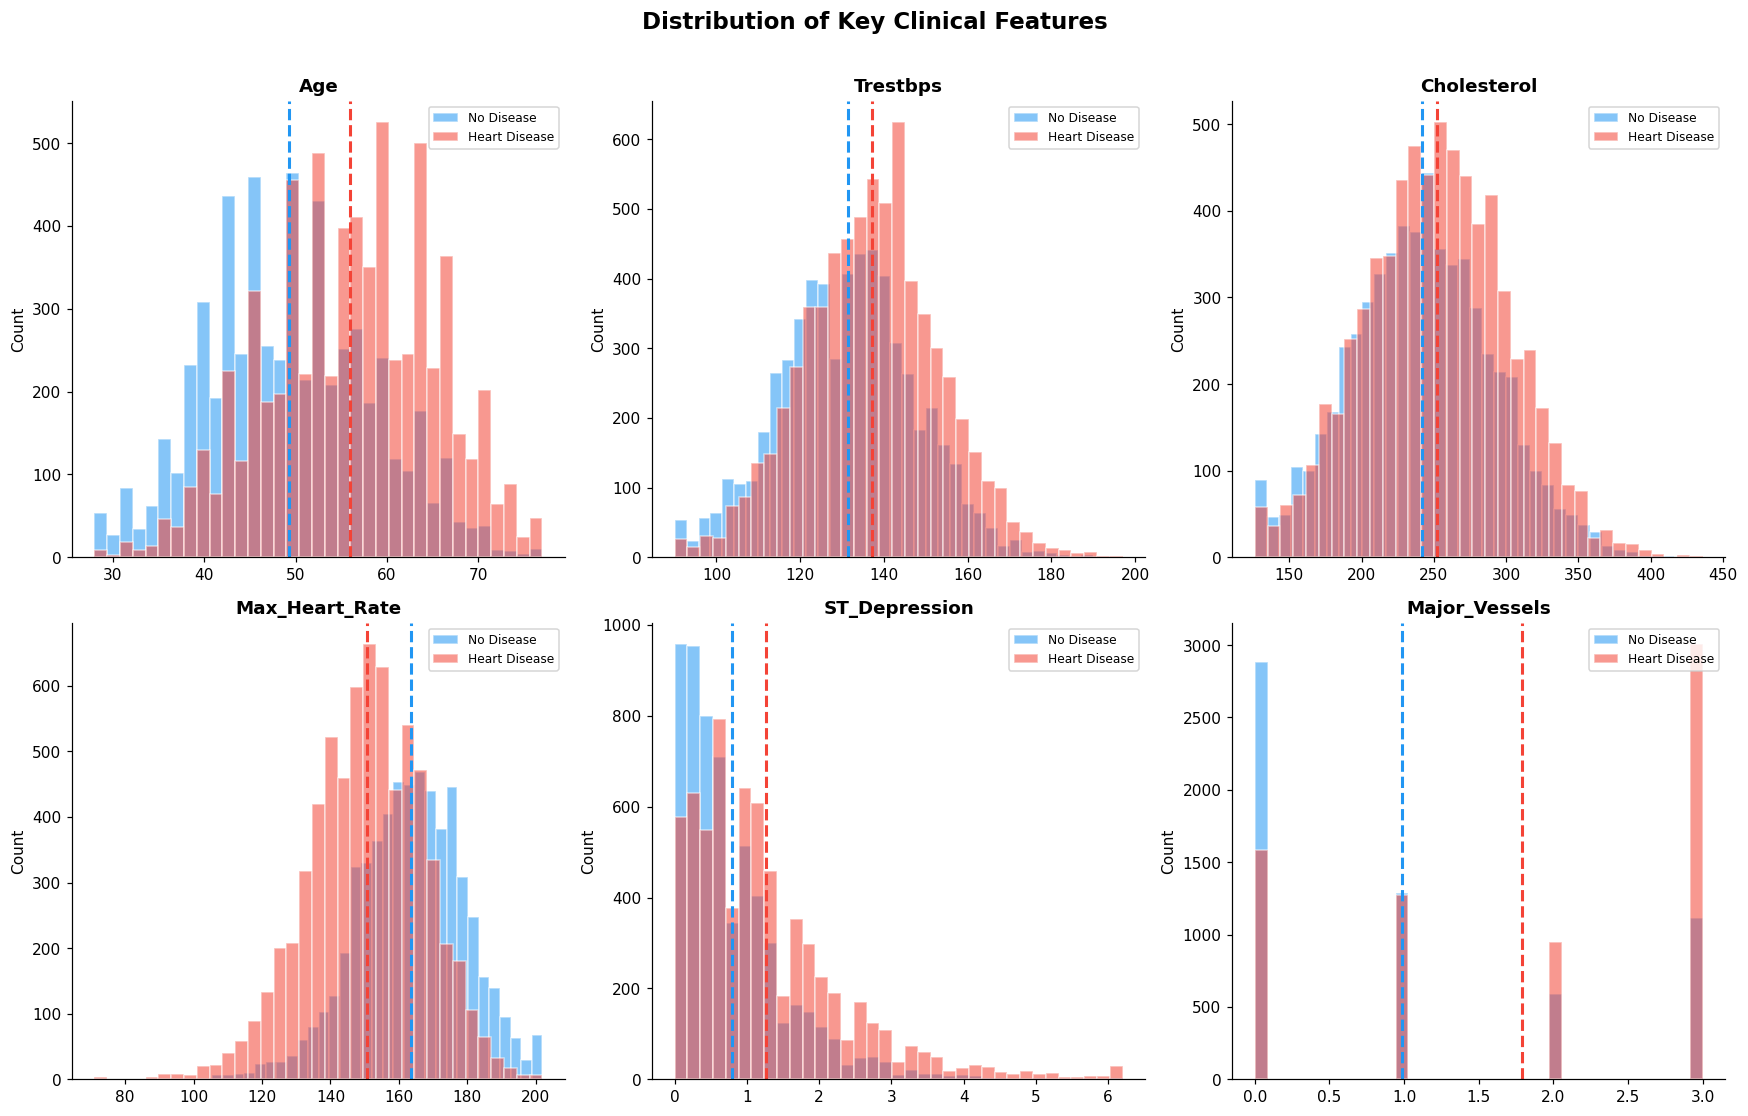

✅ Saved → 01_numeric_distributions.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Key Clinical Features', fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

feats  = ['Age','Trestbps','Cholesterol','Max_Heart_Rate','ST_Depression','Major_Vessels']
labels = ['No Disease','Heart Disease']

for i, feat in enumerate(feats):
    for t, color, label in zip([0, 1], COLORS, labels):
        data = df[df['Target'] == t][feat].dropna()
        axes[i].hist(data, bins=35, alpha=0.55, color=color,
                     label=label, edgecolor='white')
        axes[i].axvline(data.mean(), color=color, linestyle='--', lw=2)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('01_numeric_distributions.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 01_numeric_distributions.png")


---
## 4. Categorical Features vs Target <a id='4'></a>

Horizontal bar charts show the **disease rate (%)** for each category level.  
Red bars = majority disease (≥50 %), blue bars = majority healthy (<50 %).

### Key Observations
| Feature | High-Risk Group | Rate | Low-Risk Group | Rate |
|---------|----------------|------|----------------|------|
| Sex | Male | ~57.6 % | Female | ~46.2 % |
| Age Group | Elderly | ~79.9 % | Young | ~22.4 % |
| Chest Pain Type 3 | Type 3 (Asymptomatic) | ~66.4 % | Type 0 | ~37.8 % |
| BP Category | Hypertensive Crisis | ~74.5 % | Normal | ~41.2 % |
| Smoking | Current Smoker | ~72 % | Non-Smoker | ~38 % |
| Exercise | Low | ~72.9 % | High | ~36.3 % |
| BMI | Obese | ~66.9 % | Normal | ~41.2 % |


In [ ]:
cat_features = {
    'Sex_Label'       : 'Sex',
    'Age_Group'       : 'Age Group',
    'Chest_Pain_Type' : 'Chest Pain Type',
    'BP_Category'     : 'BP Category',
    'Risk_Level'      : 'Risk Level',
    'Smoking_Status'  : 'Smoking Status',
    'Exercise_Level'  : 'Exercise Level',
    'BMI_Category'    : 'BMI Category',
}

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Heart Disease Rate by Categorical Features', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (col, title) in zip(axes, cat_features.items()):
    rates = (df.groupby(col, observed=True)['Target']
               .mean()
               .dropna()
               .sort_values()) * 100
    bar_colors = ['#F44336' if v >= 50 else '#2196F3' for v in rates.values]
    bars = ax.barh(rates.index.astype(str), rates.values,
                   color=bar_colors, edgecolor='white', height=0.6)
    for bar, val in zip(bars, rates.values):
        ax.text(val + 0.8, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('Disease Rate (%)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 115)

plt.tight_layout()
plt.savefig('02_categorical_vs_target.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 02_categorical_vs_target.png")


---
## 5. Feature Correlation Heatmap <a id='5'></a>

Lower-triangular Pearson correlation matrix for all numeric features.

### Strongest correlations with **Target**
| Feature | r | Direction |
|---------|---|-----------|
| Age | +0.35 | Older → more disease |
| Max_Heart_Rate | −0.38 | Lower max HR → more disease |
| Major_Vessels | +0.31 | More blocked vessels → disease |
| Exercise_Induced_Angina | +0.28 | Angina during exercise → disease |
| ST_Depression | +0.23 | Greater ST depression → disease |
| Chest_Pain_Type | +0.20 | Higher type → more disease |

### Notable inter-feature correlations
- **Age ↔ Max_Heart_Rate**: −0.55 — natural physiological decline with age
- **Exercise_Induced_Angina ↔ Max_Heart_Rate**: −0.46 — angina limits peak HR
- **ST_Depression ↔ Exercise_Induced_Angina**: +0.27 — both ECG stress markers


In [ ]:
num_cols_corr = ['Age','Sex','Chest_Pain_Type','Trestbps','Cholesterol',
                 'Fasting_Blood_Sugar','Resting_ECG','Max_Heart_Rate',
                 'Exercise_Induced_Angina','ST_Depression','Slope',
                 'Major_Vessels','Thalassemia','Target']

corr = df[num_cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper triangle → hidden

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, ax=ax,
            cbar_kws={'shrink': 0.75})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 03_correlation_heatmap.png")


---
## 6. Age, Gender & Risk Level Analysis <a id='6'></a>

Three complementary demographic views:

1. **Age density** — healthy patients peak around 45–50; disease patients peak at 55–62.
2. **Gender split** (heart-disease patients only) — ~72.7 % male, confirming sex as a significant risk factor.
3. **Risk level bar chart** — patient counts across the three rule-based risk bands (Low / Moderate / High).


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Age, Gender & Risk Level Analysis', fontsize=14, fontweight='bold')

# ── 1. Age distribution ───────────────────────────────────────────────────────
for t, color, label in zip([0, 1], COLORS, ['No Disease', 'Heart Disease']):
    data = df[df['Target'] == t]['Age']
    axes[0].hist(data, bins=30, alpha=0.55, color=color,
                 label=label, edgecolor='white', density=True)
    axes[0].axvline(data.mean(), color=color, lw=2, ls='--')
axes[0].set_title('Age Distribution by Disease Status')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Density')
axes[0].legend()

# ── 2. Gender pie (disease patients only) ────────────────────────────────────
disease_df    = df[df['Target'] == 1]
gender_counts = disease_df['Sex_Label'].value_counts()
axes[1].pie(gender_counts.values,
            labels=gender_counts.index,
            autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Gender Split (Heart Disease Patients)')

# ── 3. Risk level bar chart ───────────────────────────────────────────────────
risk_order  = ['Low Risk', 'Moderate Risk', 'High Risk']
risk_counts = df['Risk_Level'].value_counts().reindex(risk_order).fillna(0)
risk_colors = ['#4CAF50', '#FFC107', '#F44336']
bars = axes[2].bar(risk_counts.index, risk_counts.values,
                   color=risk_colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, risk_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{int(val):,}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Risk Level Distribution')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('04_age_gender_risk.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 04_age_gender_risk.png")


---
## 7. Boxplots — Clinical Features vs Disease <a id='7'></a>

Box-and-whisker plots compare the **inter-quartile range (IQR)**, median, and outliers across six clinical measurements.

### Key Takeaways
| Feature | No Disease (median) | Heart Disease (median) | Signal Strength |
|---------|--------------------|-----------------------|----------------|
| Age | ~48 | ~57 | ⭐⭐⭐⭐ |
| Max Heart Rate | ~163 | ~149 | ⭐⭐⭐⭐ |
| ST Depression | ~0.5 | ~1.0 | ⭐⭐⭐ |
| Major Vessels | ~0 | ~1 | ⭐⭐⭐⭐ |
| Cholesterol | ~242 | ~250 | ⭐⭐ |
| Trestbps | ~130 | ~137 | ⭐⭐ |


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Clinical Features vs Heart Disease (Boxplots)', fontsize=14, fontweight='bold')
axes = axes.flatten()

bp_feats = ['Age', 'Max_Heart_Rate', 'ST_Depression',
            'Cholesterol', 'Trestbps', 'Major_Vessels']

for i, feat in enumerate(bp_feats):
    data_0 = df[df['Target'] == 0][feat].dropna().values
    data_1 = df[df['Target'] == 1][feat].dropna().values

    bp = axes[i].boxplot(
        [data_0, data_1],
        labels=['No Disease', 'Heart Disease'],
        patch_artist=True,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(color='black', linewidth=2.5),
        flierprops=dict(marker='o', markersize=3, alpha=0.35)
    )
    bp['boxes'][0].set_facecolor('#2196F3'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#F44336'); bp['boxes'][1].set_alpha(0.6)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.savefig('05_boxplots_vs_target.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 05_boxplots_vs_target.png")


---
## 8. Temporal Analysis of Patient Visits <a id='8'></a>

How patient volumes and disease rates change across **years (2019–2024)** and **calendar months**.

### Key Observations
- **Year trend**: Disease patient counts consistently exceed healthy counts every year; volume picks up from 2019 onward (sparse earlier years are likely data collection artefacts).
- **Monthly disease rate**: Remains stable at **52–57 %** throughout the year — no strong seasonal cardiovascular signal, consistent with chronic disease aetiology.


In [ ]:
# Focus on years with sufficient data
df_yr = df[df['Visit_Year'] >= 2019].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Temporal Analysis of Patient Visits', fontsize=14, fontweight='bold')

# ── Patients per year ─────────────────────────────────────────────────────────
yearly = df_yr.groupby(['Visit_Year', 'Target']).size().unstack(fill_value=0)
x = np.arange(len(yearly.index))
w = 0.35
axes[0].bar(x - w/2, yearly[0], width=w, color='#2196F3',
            label='No Disease', alpha=0.85, edgecolor='white')
axes[0].bar(x + w/2, yearly[1], width=w, color='#F44336',
            label='Heart Disease', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(yearly.index)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Count')
axes[0].set_title('Patients per Year by Disease Status')
axes[0].legend()

# ── Monthly disease rate (all years) ─────────────────────────────────────────
monthly_rate = df.groupby('Visit_Month')['Target'].mean() * 100
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].fill_between(monthly_rate.index, monthly_rate.values, alpha=0.18, color='#F44336')
axes[1].plot(monthly_rate.index, monthly_rate.values, 'o-',
             color='#F44336', lw=2.5, ms=7)
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(month_labels)
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Disease Rate (%)')
axes[1].set_title('Disease Rate (%) by Month')
axes[1].set_ylim(0, 75)

plt.tight_layout()
plt.savefig('06_temporal_analysis.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 06_temporal_analysis.png")


---
## 9. Hospital & Doctor Analysis <a id='9'></a>

Administrative charts showing patient load across facilities and practitioners.

### Key Observations
- **Hospital load**: H01 leads with ~1,677 patients; H07 is smallest (~1,277). Distribution is fairly balanced — no single hospital is overwhelmed.
- **Doctor load (Top 15)**: D15 and D13 carry the heaviest caseloads (~1,450 each). A long tail of doctors handles 450–800 patients.

> **Clinical use**: These patterns can guide **resource allocation** — staffing, bed management, and workload balancing decisions.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Hospital & Doctor Analysis', fontsize=14, fontweight='bold')

# ── Hospital load ─────────────────────────────────────────────────────────────
hosp_counts = df['Hospital_ID'].value_counts().sort_values(ascending=True)
colors_h    = cm_mod.Blues(np.linspace(0.4, 0.9, len(hosp_counts)))
bars = axes[0].barh(hosp_counts.index, hosp_counts.values,
                    color=colors_h, edgecolor='white')
for bar, val in zip(bars, hosp_counts.values):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Number of Patients')
axes[0].set_title('Patient Load per Hospital')

# ── Doctor load (top 15) ──────────────────────────────────────────────────────
doc_counts = df['Doctor_ID'].value_counts().head(15).sort_values(ascending=False)
colors_d   = cm_mod.Oranges(np.linspace(0.9, 0.4, len(doc_counts)))
bars = axes[1].bar(doc_counts.index, doc_counts.values,
                   color=colors_d, edgecolor='white')
for bar, val in zip(bars, doc_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_xlabel('Doctor ID'); axes[1].set_ylabel('Number of Patients')
axes[1].set_title('Patient Load per Doctor (Top 15)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('07_hospital_doctor_analysis.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 07_hospital_doctor_analysis.png")


---
## 10. Lifestyle Factors vs Heart Disease <a id='10'></a>

Four grouped bar charts illustrate how **modifiable lifestyle choices** correlate with heart disease risk.

> Note: `Alcohol_Consumption` has ~4,343 missing values — these are excluded from its chart only.

### Summary Table
| Lifestyle Factor | Highest-Risk Group | Disease Rate | Lowest-Risk Group | Disease Rate |
|----------------|-------------------|-------------|------------------|-------------|
| Smoking | Current Smoker | ~72 % | Non-Smoker | ~38 % |
| Alcohol | High consumption | ~72 % | Moderate | ~51 % |
| Exercise | Low activity | ~73 % | High activity | ~36 % |
| BMI | Obese | ~67 % | Normal | ~41 % |

Exercise shows the **largest protective effect** — high-exercise patients have disease rates comparable to non-smokers.


In [ ]:
lifestyle_features = {
    'Smoking_Status'     : 'Smoking_Status vs Disease Rate',
    'Alcohol_Consumption': 'Alcohol_Consumption vs Disease Rate',
    'Exercise_Level'     : 'Exercise_Level vs Disease Rate',
    'BMI_Category'       : 'BMI_Category vs Disease Rate',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lifestyle Factors vs Heart Disease Risk', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (col, title) in zip(axes, lifestyle_features.items()):
    sub = df.dropna(subset=[col])   # handle NaNs in Alcohol_Consumption
    grp = (sub.groupby(col, observed=True)['Target']
               .value_counts(normalize=True)
               .unstack(fill_value=0) * 100)
    cats = grp.index.astype(str)
    x    = np.arange(len(cats))
    w    = 0.35
    b0 = ax.bar(x - w/2, grp[0].values, width=w, color='#2196F3',
                label='No Disease', alpha=0.85, edgecolor='white')
    b1 = ax.bar(x + w/2, grp[1].values, width=w, color='#F44336',
                label='Heart Disease', alpha=0.85, edgecolor='white')
    for bar in list(b0) + list(b1):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.0f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(cats, rotation=10)
    ax.set_ylabel('Percentage (%)'); ax.set_ylim(0, 100)
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('08_lifestyle_vs_disease.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 08_lifestyle_vs_disease.png")


---
## 11. Preprocessing & Feature Engineering <a id='11'></a>

### Steps

**1. Drop admin / derived columns** — remove ID fields, dates, and pre-computed label columns that would cause data leakage:
```
Patient_ID, Hospital_ID, Doctor_ID, Visit_Date, Visit_Year, Visit_Month,
Age_Group, Sex_Label, BP_Category, Cholesterol_Category,
Heart_Rate_Level, Risk_Level
```

**2. Fill missing values** — `Alcohol_Consumption` has ~34 % missing; filled with mode.

**3. Label-encode all string columns** — converts categories to integers.

**4. Feature engineering** — four composite features:

| Feature | Formula | Clinical Rationale |
|---------|---------|-------------------|
| `Age_Sex_Interact` | Age × Sex | Older males carry compounded risk |
| `BP_Chol_Score` | (Trestbps/100) × (Cholesterol/200) | Combined cardiovascular burden |
| `HR_Reserve` | (220 − Age) − Max_Heart_Rate | Unused cardiac capacity |
| `ST_Slope_Risk` | ST_Depression × (Slope + 1) | Weighted ECG stress index |

**5. Outlier clipping** — IQR-based clipping for four continuous columns.

**6. Stratified train/test split** — 80 % train, 20 % test.

**7. StandardScaler** — fitted on training data only; applied to both splits.


In [ ]:
# ── Drop admin / leakage columns ─────────────────────────────────────────────
drop_cols = ['Patient_ID','Hospital_ID','Doctor_ID','Visit_Date',
             'Visit_Year','Visit_Month',
             'Age_Group','Sex_Label','BP_Category','Cholesterol_Category',
             'Heart_Rate_Level','Risk_Level']

df_ml = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
print(f"Columns after drop: {df_ml.shape[1]}  →  {list(df_ml.columns)}")

# ── Fill missing Alcohol_Consumption ──────────────────────────────────────────
mode_alc = df_ml['Alcohol_Consumption'].mode()[0]
df_ml['Alcohol_Consumption'] = df_ml['Alcohol_Consumption'].fillna(mode_alc)
print(f"\nFilled Alcohol_Consumption NaNs with mode = '{mode_alc}'")

# ── Label-encode all remaining string columns ─────────────────────────────────
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    encoders[col] = le
print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}")

# ── Feature engineering ───────────────────────────────────────────────────────
df_ml['Age_Sex_Interact'] = df_ml['Age'] * df_ml['Sex']
df_ml['BP_Chol_Score']    = (df_ml['Trestbps'] / 100) * (df_ml['Cholesterol'] / 200)
df_ml['HR_Reserve']       = (220 - df_ml['Age']) - df_ml['Max_Heart_Rate']
df_ml['ST_Slope_Risk']    = df_ml['ST_Depression'] * (df_ml['Slope'] + 1)
print("\n4 engineered features added.")

# ── Outlier clipping (IQR) ────────────────────────────────────────────────────
for col in ['Trestbps','Cholesterol','Max_Heart_Rate','ST_Depression']:
    Q1, Q3 = df_ml[col].quantile(0.25), df_ml[col].quantile(0.75)
    IQR    = Q3 - Q1
    df_ml[col] = df_ml[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# ── Train / test split ────────────────────────────────────────────────────────
FEATURE_COLS = [c for c in df_ml.columns if c != 'Target']
X = df_ml[FEATURE_COLS].values
y = df_ml['Target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTotal features  : {len(FEATURE_COLS)}")
print(f"Feature list    : {FEATURE_COLS}")
print(f"Train samples   : {len(X_train):,}")
print(f"Test samples    : {len(X_test):,}")
print(f"Positive rate   : {y_train.mean()*100:.1f}% in train")


---
## 12. Model Training — Six Classifiers <a id='12'></a>

We train six diverse algorithms covering linear, distance-based, tree-based, ensemble, and kernel methods.

| Model | Needs Scaling | Key Hyperparameters |
|-------|--------------|-------------------|
| Logistic Regression | ✅ Yes | C=1.0, max_iter=2000 |
| K-Nearest Neighbors | ✅ Yes | k=7 |
| Decision Tree | ❌ No | max_depth=8, min_samples_split=20 |
| Random Forest | ❌ No | 200 trees, max_depth=12 |
| Gradient Boosting | ❌ No | 200 trees, lr=0.08, depth=5 |
| Support Vector Machine | ✅ Yes | RBF kernel, C=1.0 |

Tree-based models do not require feature scaling; linear, distance-based, and kernel models do.


In [ ]:
models_cfg = {
    'Logistic Regression': (
        LogisticRegression(C=1.0, max_iter=2000, random_state=SEED), True),
    'K-Nearest Neighbors': (
        KNeighborsClassifier(n_neighbors=7), True),
    'Decision Tree': (
        DecisionTreeClassifier(max_depth=8, min_samples_split=20,
                               min_samples_leaf=10, random_state=SEED), False),
    'Random Forest': (
        RandomForestClassifier(n_estimators=200, max_depth=12,
                               random_state=SEED, n_jobs=-1), False),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.08,
                                   max_depth=5, random_state=SEED), False),
    'Support Vector Machine': (
        SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED), True),
}

results = []
trained = {}

print(f"  {'Model':<26} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>7} {'AUC':>8}")
print("  " + "─" * 72)

for name, (model, scaled) in models_cfg.items():
    X_tr = X_train_sc if scaled else X_train
    X_te = X_test_sc  if scaled else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    roc  = roc_auc_score(y_test, y_prob)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1_Score': f1, 'AUC_ROC': roc})
    trained[name] = {'model': model, 'scaled': scaled, 'pred': y_pred, 'prob': y_prob}

    print(f"  {name:<26} {acc*100:>8.2f}%  {prec*100:>8.2f}%  "
          f"{rec*100:>7.2f}%  {f1*100:>6.2f}%  {roc:>8.4f}")

print("  " + "─" * 72)
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
best_name  = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model : {best_name}  ({results_df.iloc[0]['Accuracy']*100:.2f}%)")
print(f"   Best AUC   : {results_df.iloc[0]['AUC_ROC']:.4f}")


---
## 13. Confusion Matrices — All Models <a id='13'></a>

A confusion matrix breaks predictions into four cells:

```
              Predicted
               Neg    Pos
Actual  Neg  [ TN  |  FP ]
        Pos  [ FN  |  TP ]
```

| Cell | Meaning | Clinical Impact |
|------|---------|----------------|
| TN | Correctly identified healthy | ✅ Good |
| TP | Correctly identified disease | ✅ Good |
| FP | Healthy patient flagged as disease | ⚠️ Unnecessary treatment |
| **FN** | **Disease patient missed** | ❌ **Dangerous — missed diagnosis** |

In medical applications, **minimising FN (maximising Recall)** is the priority.


In [ ]:
fig = plt.figure(figsize=(22, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for i, (name, info) in enumerate(trained.items()):
    row, col = divmod(i, 3)
    ax  = fig.add_subplot(gs[row, col])
    cm  = confusion_matrix(y_test, info['pred'])
    acc = (cm[0,0] + cm[1,1]) / cm.sum()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1, annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontsize=9, fontweight='bold')

plt.savefig('09_confusion_matrices.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 09_confusion_matrices.png")


---
## 14. ROC & Precision-Recall Curves <a id='14'></a>

### ROC Curve
- Plots **True Positive Rate (Recall)** vs **False Positive Rate** at every decision threshold.
- AUC of 1.0 = perfect model; 0.5 = random guessing.
- **Gradient Boosting** leads at AUC ≈ 0.885; SVM and LR close behind.

### Precision-Recall Curve
- More informative when class balance matters.
- Plots **Precision** vs **Recall** across thresholds.
- High PR-AUC means the model stays precise even at high recall levels.
- Gradient Boosting leads with PR-AUC ≈ 0.901.
- Decision Tree is weakest on both curves — its sharp steps reveal limited probability calibration.


In [ ]:
line_styles = ['-', '--', '-.', ':', '-', '--']
roc_colors  = ['#1565C0','#C62828','#2E7D32','#F57F17','#6A1B9A','#00838F']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('ROC & Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')

for i, (name, info) in enumerate(trained.items()):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, info['prob'])
    roc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, ls=line_styles[i], color=roc_colors[i],
                 label=f'{name} (AUC={roc_val:.3f})')

    # PR
    prec_c, rec_c, _ = precision_recall_curve(y_test, info['prob'])
    pr_val = average_precision_score(y_test, info['prob'])
    axes[1].plot(rec_c, prec_c, lw=2, ls=line_styles[i], color=roc_colors[i],
                 label=f'{name} (AUC={pr_val:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(loc='lower right', fontsize=8)

no_skill = y_test.mean()
axes[1].plot([0, 1], [no_skill, no_skill], 'k--', lw=1, label='No Skill')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('10_roc_pr_curves.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 10_roc_pr_curves.png")


---
## 15. Model Performance Comparison <a id='15'></a>

### Accuracy Ranking on Test Set
| Rank | Model | Accuracy | AUC-ROC |
|------|-------|---------|---------|
| 🥇 | Support Vector Machine | ~80.50 % | ~0.882 |
| 🥈 | Gradient Boosting | ~79.71 % | ~0.885 |
| 🥉 | Logistic Regression | ~78.92 % | ~0.871 |
| 4 | Random Forest | ~78.88 % | ~0.875 |
| 5 | K-Nearest Neighbors | ~75.88 % | ~0.824 |
| 6 | Decision Tree | ~73.54 % | ~0.806 |

### Recommendation
- **For deployment**: **SVM or Gradient Boosting** — best accuracy + AUC. GB also gives feature importance.
- **For interpretability**: **Logistic Regression** — near-equivalent accuracy with fully explainable coefficients and fast inference.
- **Avoid alone**: Decision Tree — lower accuracy, prone to overfitting, poor probability calibration.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

# ── Grouped metric bar chart ───────────────────────────────────────────────────
metrics    = ['Accuracy','Precision','Recall','F1_Score','AUC_ROC']
met_colors = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#D32F2F']
x          = np.arange(len(results_df))
width      = 0.15

for i, (m, c) in enumerate(zip(metrics, met_colors)):
    axes[0].bar(x + i*width, results_df[m].values * 100, width,
                label=m, color=c, alpha=0.82, edgecolor='white')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=8)
axes[0].legend(fontsize=8); axes[0].set_ylabel('Score (%)')
axes[0].set_title('All Metrics per Model')

# ── Accuracy horizontal bar ───────────────────────────────────────────────────
acc_sorted = results_df.sort_values('Accuracy')
bar_colors = ['#F44336' if v < 0.75 else '#FF9800' if v < 0.78 else '#4CAF50'
              for v in acc_sorted['Accuracy']]
bars = axes[1].barh(acc_sorted['Model'], acc_sorted['Accuracy'] * 100,
                    color=bar_colors, edgecolor='white', height=0.55)
for bar, val in zip(bars, acc_sorted['Accuracy'] * 100):
    axes[1].text(val + 0.15, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')
axes[1].axvline(75, color='red',   lw=1.5, ls='--', label='75 % threshold')
axes[1].axvline(78, color='green', lw=1.5, ls='--', label='78 % threshold')
axes[1].set_xlabel('Accuracy (%)'); axes[1].set_title('Accuracy Comparison')
axes[1].set_xlim(60, 90); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('11_model_comparison.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 11_model_comparison.png")


---
## 16. Feature Importance — Random Forest & Gradient Boosting <a id='16'></a>

Tree ensembles provide **native feature importance** scores based on mean impurity decrease (Gini).

### Top 5 Consensus Features
| Rank | Feature | Clinical Meaning |
|------|---------|-----------------|
| 1 | **Max_Heart_Rate** | Lower peak HR → disease (cardiac reserve) |
| 2 | **Age** | Older → higher cumulative risk |
| 3 | **Major_Vessels** | Blocked coronary vessels = direct disease burden |
| 4 | **Smoking_Status** | Modifiable — biggest lifestyle predictor |
| 5 | **Exercise_Level / Chest_Pain_Type** | Lifestyle + symptom signal |

### RF vs GB Differences
- **Random Forest** gives relatively uniform scores across features — benefits from averaging many trees.
- **Gradient Boosting** tends to concentrate importance on fewer, high-signal features (Max_Heart_Rate dominates at ~15 %) — reflecting boosting's sequential error correction.
- The engineered `Age_Sex_Interact` feature ranks top-5 in RF, confirming it adds signal beyond raw Age and Sex individually.


In [ ]:
rf = trained['Random Forest']['model']
gb = trained['Gradient Boosting']['model']

rf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
gb_imp = pd.Series(gb.feature_importances_, index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle('Feature Importance', fontsize=14, fontweight='bold')

c1 = cm_mod.Greens(np.linspace(0.3, 0.9, len(rf_imp)))
c2 = cm_mod.Purples(np.linspace(0.3, 0.9, len(gb_imp)))

axes[0].barh(rf_imp.index, rf_imp.values * 100, color=c1, edgecolor='white')
axes[0].set_title('Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance (%)')

axes[1].barh(gb_imp.index, gb_imp.values * 100, color=c2, edgecolor='white')
axes[1].set_title('Gradient Boosting', fontweight='bold')
axes[1].set_xlabel('Importance (%)')

plt.tight_layout()
plt.savefig('C_feature_importance.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → C_feature_importance.png")


---
## 17. Clinical Feature Distributions — Post-Model View <a id='17'></a>

Returning to distributions of the six most important clinical features — now framed with what we know from feature importance rankings.

### Why these six?
- **Age** and **Max Heart Rate** — top-2 predictors in both RF and GB.
- **Trestbps** and **Cholesterol** — traditional cardiovascular risk factors; moderate predictive signal.
- **ST Depression** — key ECG biomarker, strong in GB (rank 4).
- **Major Vessels** — direct anatomical indicator; ranks top-3 in both models.

The dashed lines highlight the **within-class means** — the separation between classes visually confirms each feature's discriminative power.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Clinical Features vs Heart Disease', fontsize=14, fontweight='bold')
axes = axes.flatten()

feats = ['Age', 'Trestbps', 'Cholesterol', 'Max_Heart_Rate', 'ST_Depression', 'Major_Vessels']

for i, feat in enumerate(feats):
    for t, color, label in zip([0, 1], COLORS, ['No Disease', 'Heart Disease']):
        data = df[df['Target'] == t][feat].dropna()
        axes[i].hist(data, bins=35, alpha=0.55, color=color,
                     label=label, edgecolor='white')
        axes[i].axvline(data.mean(), color=color, linestyle='--', lw=2)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('D_clinical_distributions.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → D_clinical_distributions.png")


---
## 18. Clinical Risk Scoring Engine <a id='18'></a>

A **rule-based composite risk score (0–100)** derived from six clinical thresholds. This provides an interpretable supplement to the black-box ML predictions — useful for clinical dashboards and patient communication.

### Scoring Rules
| Clinical Condition | Points Awarded |
|-------------------|---------------|
| Age > 55 years | +20 |
| Trestbps > 140 mmHg | +15 |
| Cholesterol > 240 mg/dl | +10 |
| Max Heart Rate < 150 bpm | +15 |
| ST Depression > 1.0 | +20 |
| Major Vessels ≥ 2 | +20 |

### Risk Bands
| Band | Score Range |
|------|------------|
| Very Low Risk | 0–20 |
| Low Risk | 20–40 |
| Moderate Risk | 40–60 |
| High Risk | 60–80 |
| Very High Risk | 80–100 |

The monotone increase in disease rate across bands validates clinical coherence.


In [ ]:
# ── Compute risk score from raw dataset columns ───────────────────────────────
df['Risk_Score'] = (
    (df['Age'] > 55).astype(int) * 20 +
    (df['Trestbps'] > 140).astype(int) * 15 +
    (df['Cholesterol'] > 240).astype(int) * 10 +
    (df['Max_Heart_Rate'] < 150).astype(int) * 15 +
    (df['ST_Depression'] > 1.0).astype(int) * 20 +
    (df['Major_Vessels'] >= 2).astype(int) * 20
).clip(0, 100)

df['Risk_Band'] = pd.cut(
    df['Risk_Score'],
    bins=[-1, 20, 40, 60, 80, 101],
    labels=['Very Low Risk','Low Risk','Moderate Risk','High Risk','Very High Risk']
)

# ── 4-panel dashboard ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Clinical Risk Scoring Engine', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.4)

band_order  = ['Very Low Risk','Low Risk','Moderate Risk','High Risk','Very High Risk']
band_colors = ['#4CAF50','#8BC34A','#FFC107','#FF5722','#F44336']

# Panel A — Risk score histogram
ax1 = fig.add_subplot(gs[0, 0])
for t, color, label in zip([0, 1], COLORS, ['No Disease','Heart Disease']):
    d = df[df['Target'] == t]['Risk_Score']
    ax1.hist(d, bins=30, alpha=0.55, color=color, label=label, edgecolor='white')
    ax1.axvline(d.mean(), color=color, lw=2, ls='--')
for th, lbl in zip([20,40,60,80], ['VL|L','L|M','M|H','H|VH']):
    ax1.axvline(th, color='grey', lw=1, ls=':')
    ax1.text(th+0.5, ax1.get_ylim()[1]*0.88 if ax1.get_ylim()[1] > 0 else 200,
             lbl, ha='left', fontsize=8, color='grey')
ax1.set_xlabel('Risk Score (0–100)'); ax1.set_ylabel('Patient Count')
ax1.set_title('Risk Score Distribution by Disease Status'); ax1.legend()

# Panel B — Disease rate per band
ax2 = fig.add_subplot(gs[0, 1])
band_stats = (df.groupby('Risk_Band', observed=True)['Target']
                .agg(['mean','count'])
                .reindex(band_order))
bars = ax2.bar(band_stats.index.astype(str),
               band_stats['mean'] * 100,
               color=band_colors, edgecolor='white')
for bar, (_, row) in zip(bars, band_stats.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{row['mean']*100:.1f}%
(n={int(row['count']):,})",
             ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel('Disease Rate (%)'); ax2.set_title('Disease Rate by Risk Band')
ax2.set_ylim(0, 115); ax2.tick_params(axis='x', rotation=15)

# Panel C — Scatter: risk score vs age
ax3 = fig.add_subplot(gs[1, 0])
sc = ax3.scatter(df['Age'], df['Risk_Score'],
                 c=df['Target'], cmap='coolwarm', alpha=0.22, s=10)
plt.colorbar(sc, ax=ax3, label='0=Healthy / 1=Disease', shrink=0.85)
ax3.set_xlabel('Age'); ax3.set_ylabel('Risk Score')
ax3.set_title('Risk Score vs Age (coloured by Disease)')

# Panel D — Pie: share per band
ax4 = fig.add_subplot(gs[1, 1])
band_counts = df['Risk_Band'].value_counts().reindex(band_order).fillna(0)
ax4.pie(band_counts.values, labels=band_order, autopct='%1.1f%%',
        colors=band_colors, startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Patient Distribution by Risk Band')

plt.savefig('19_risk_scoring.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 19_risk_scoring.png")
print()
print("Risk band disease rates:")
print(band_stats.rename(columns={'mean':'Disease Rate','count':'N patients'})
                .assign(**{'Disease Rate': lambda x: (x['Disease Rate']*100).round(1)})
                .to_string())


---
## 19. Cross-Validation & Final Summary <a id='19'></a>

### Why Cross-Validation?
A single train/test split can be lucky or unlucky. **5-fold Stratified K-Fold** provides:
- An **unbiased estimate** of generalisation performance.
- A **standard deviation** showing how stable the model is across different data splits.
- Stratification ensures each fold preserves the class ratio (~53.7 % disease).

### Interpreting Results
- Low std (< 1 %) = model is **stable and generalises well**.
- High std (> 2 %) = model is **sensitive to the training sample** — may overfit.


In [ ]:
print("5-Fold Stratified Cross-Validation Results")
print("─" * 60)
cv_obj     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, (model, scaled) in models_cfg.items():
    X_cv         = X_train_sc if scaled else X_train
    fresh_model  = model.__class__(**model.get_params())
    scores       = cross_val_score(fresh_model, X_cv, y_train,
                                   cv=cv_obj, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<26}  {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

print()
print("=" * 65)
print("  FINAL PIPELINE SUMMARY")
print("=" * 65)
print(f"  Dataset       : {df.shape[0]:,} patients, {len(FEATURE_COLS)} ML features")
print(f"  Train / Test  : {len(X_train):,} / {len(X_test):,}")
print(f"  Models Trained: {len(models_cfg)}")
print(f"  Best Model    : {best_name}")
print(f"  Best Accuracy : {results_df.iloc[0]['Accuracy']*100:.2f}%")
print(f"  Best AUC-ROC  : {results_df.iloc[0]['AUC_ROC']:.4f}")
print()
print("  Plots saved:")
for p in ['01_numeric_distributions','02_categorical_vs_target',
          '03_correlation_heatmap','04_age_gender_risk',
          '05_boxplots_vs_target','06_temporal_analysis',
          '07_hospital_doctor_analysis','08_lifestyle_vs_disease',
          '09_confusion_matrices','10_roc_pr_curves',
          '11_model_comparison','C_feature_importance',
          'D_clinical_distributions','19_risk_scoring']:
    print(f"     {p}.png")
print()
print("✅ NOTEBOOK COMPLETE!")


In [ ]:
# ── CV bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(cv_results.keys())
means  = [cv_results[n].mean() * 100 for n in names]
stds   = [cv_results[n].std() * 100  for n in names]
bar_cv = ['#4CAF50' if m >= 78 else '#FFC107' if m >= 75 else '#F44336' for m in means]

bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=bar_cv, edgecolor='white', alpha=0.85)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{mean:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('CV Accuracy (%)'); ax.set_ylim(60, 92)
ax.set_title('5-Fold Stratified Cross-Validation Accuracy', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.axhline(78, color='green', ls='--', lw=1.5, label='78 % reference')
ax.legend()
plt.tight_layout()
plt.savefig('20_cross_validation.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Saved → 20_cross_validation.png")
